In [60]:
import pandas as pd
import numpy as np

data = pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")

In [61]:
data.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [62]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB


,0
Feature1,0
Feature2,0
Target,20


In [66]:
data['Target'].unique()

array([ 1.,  0., nan])

In [67]:
data = data.dropna(subset=['Target'])

In [68]:
data['Target'].unique()

array([1., 0.])

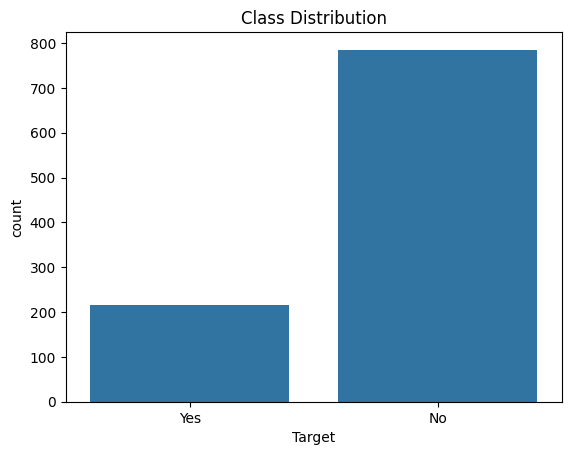

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=data)
plt.title("Class Distribution")
plt.show()

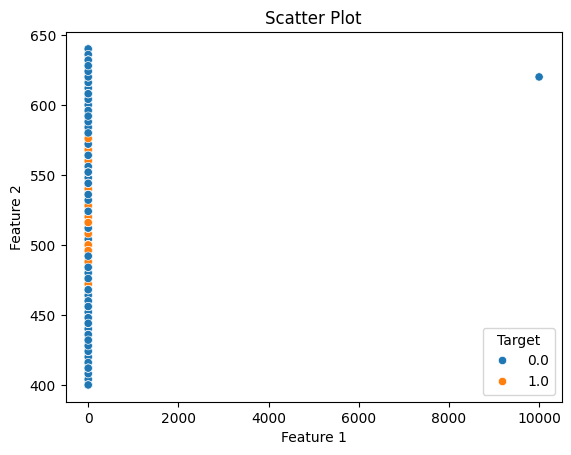

In [64]:
# Encoding
data['Target'] = data['Target'].map({'No': 0, 'Yes': 1})

sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=data)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot')
plt.show()

In [70]:
data['Feature1'].max()

10000.0

In [71]:
data = data[data['Feature1'] < 10]

In [72]:
data['Target'] = data['Target'].astype(int)

In [73]:
from sklearn.preprocessing import StandardScaler

X = data[['Feature1', 'Feature2']]
y = data['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

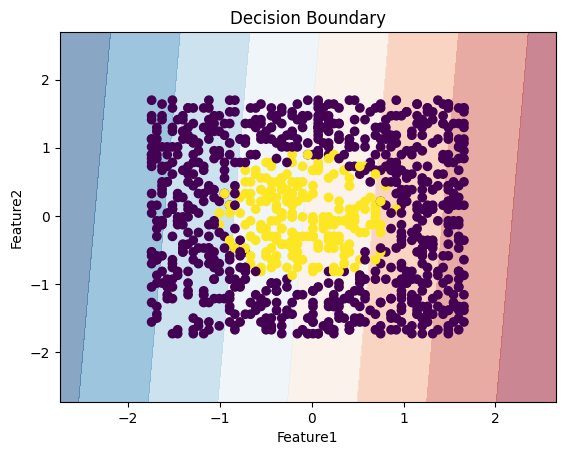

In [75]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator(
    model,
    X_scaled,
    cmap="RdBu",
    alpha=0.5,
)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.title("Decision Boundary")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [77]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.79


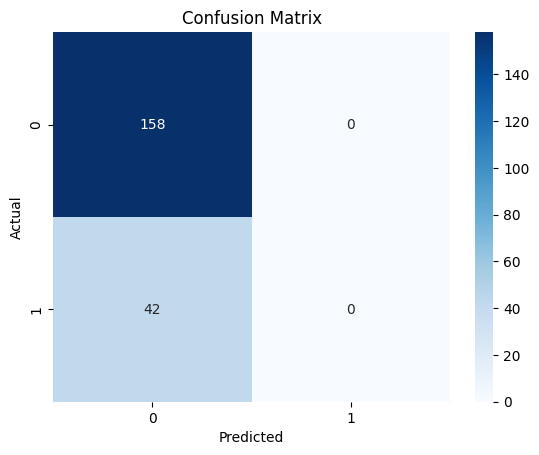

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()